# Assignment 1 (Data Analysis (Hotel Bookings))

**Name:** Sama Baraawi  


In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("hotel_bookings.csv")

In [10]:
path = r"C:\Users\user\Desktop\PythonProject\hotel_bookings.csv"

In [11]:
print(df.head(3))


          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1                        0                     0       2  ...    No Deposit   
2                        0                     1       1  ...    No Deposit   

   agent company days_in_waiting_list customer_type   adr  \
0    NaN     NaN                    0     Transient   0.0   
1  

In [12]:
numeric_columns = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'booking_changes',
    'adr',
    'required_car_parking_spaces'
]


**Selected 10 numeric columns:**  
`lead_time`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `previous_cancellations`, `booking_changes`, `adr`, `required_car_parking_spaces`.


In [13]:
df[numeric_columns] = df[numeric_columns].fillna(0)


In [14]:
for col in numeric_columns:
    mean_val = df[col].mean()
    std_val = df[col].std()
    count_val = df[col].count()
    median_val = df[col].median()
    p75_val = df[col].quantile(0.75)

    print(col)
    print("  Mean:", round(mean_val, 2))
    print("  Standard Deviation:", round(std_val, 2))
    print("  Count:", count_val)
    print("  Median:", median_val)
    print("  75th Percentile:", p75_val)
    print("------------------------")


lead_time
  Mean: 104.01
  Standard Deviation: 106.86
  Count: 119390
  Median: 69.0
  75th Percentile: 160.0
------------------------
stays_in_weekend_nights
  Mean: 0.93
  Standard Deviation: 1.0
  Count: 119390
  Median: 1.0
  75th Percentile: 2.0
------------------------
stays_in_week_nights
  Mean: 2.5
  Standard Deviation: 1.91
  Count: 119390
  Median: 2.0
  75th Percentile: 3.0
------------------------
adults
  Mean: 1.86
  Standard Deviation: 0.58
  Count: 119390
  Median: 2.0
  75th Percentile: 2.0
------------------------
children
  Mean: 0.1
  Standard Deviation: 0.4
  Count: 119390
  Median: 0.0
  75th Percentile: 0.0
------------------------
babies
  Mean: 0.01
  Standard Deviation: 0.1
  Count: 119390
  Median: 0.0
  75th Percentile: 0.0
------------------------
previous_cancellations
  Mean: 0.09
  Standard Deviation: 0.84
  Count: 119390
  Median: 0.0
  75th Percentile: 0.0
------------------------
booking_changes
  Mean: 0.22
  Standard Deviation: 0.65
  Count: 119390

Interpretation of Summary Statistics

- The **average lead time** is about **104 days**, meaning guests usually book around 3 months before their stay.
- The **average stay** during weekdays is about **2.5 nights**, and around **0.9 nights** on weekends (most visits are short stays).
- Most bookings are made by **2 adults**, while the number of children and babies is very low.
- The **average daily rate (ADR)** is around **101.8**, which represents the average room price per night.
- The **75th percentile of lead_time (160)** means that 25% of bookings were made more than 160 days in advance.
- The **standard deviation of ADR (≈50)** indicates big variation in room prices (possibly different hotel types or seasons).
- The **previous_cancellations** and **booking_changes** values are very low, showing most guests don’t modify or cancel much.
- The **required_car_parking_spaces** mean is close to 0, which means most guests don’t request a parking space.


### Question 1: What percentage of bookings were canceled?


In [15]:
#calculating all the reservations
total_bookings = len(df)

#calculating the canceled revervations
canceled_bookings = df['is_canceled'].sum()

#calculating the percantge for canceled revervations
cancel_percentage = (canceled_bookings / total_bookings) * 100

#printing results
print("Total bookings:", total_bookings)
print("Canceled bookings:", canceled_bookings)
print("Cancellation percentage:", round(cancel_percentage, 2), "%")


Total bookings: 119390
Canceled bookings: 44224
Cancellation percentage: 37.04 %


**Interpretation:**  
About **37.04%** of all bookings were canceled.  
This means that more than one-third of the guests did not complete their reservations.  
Such a high cancellation rate may indicate that hotels need stronger confirmation policies,  
clearer communication, or better incentives for guests to reduce cancellations.


### Question 2: Which hotel type has the higher average daily rate (ADR)?


In [16]:
#Calculating the average daily rate (ADR) for each hotel type
adr_by_hotel = df.groupby('hotel')['adr'].mean()

#Printing the results
print(adr_by_hotel)



hotel
City Hotel      105.304465
Resort Hotel     94.952930
Name: adr, dtype: float64


**Interpretation:**  
The results show that the **City Hotel** has a higher average daily rate (ADR) of about **105.30**, while the **Resort Hotel** has a lower ADR of about **94.95**.  
This means that city hotels are generally more expensive, possibly due to higher demand, central locations, or business related stays.


### Question 3: What is the most common length of stay (in nights)?


In [17]:
# Creating a new column that represents the total length of stay (week + weekend nights)
df['total_stay'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

# Counting how many times each total stay length appears
stay_counts = df['total_stay'].value_counts()

# Printing the top 5 most common stay lengths
print(stay_counts.head(5))


total_stay
2    27643
3    27076
1    21020
4    17383
7     8655
Name: count, dtype: int64


**Interpretation:**  
The results show that the most common stay length is **2 nights**,  
followed by **3 nights** and **1 night**.  
This indicates that most hotel guests prefer short stays, probably for weekend trips or business visits rather than long vacations.


### Question 4: Do guests with more special requests cancel less often?


In [18]:
# Calculating the average number of special requests for each cancellation group
avg_requests = df.groupby('is_canceled')['total_of_special_requests'].mean()

# Printing the results
print(avg_requests)


is_canceled
0    0.714060
1    0.328826
Name: total_of_special_requests, dtype: float64


**Interpretation:**  
Guests who **did not cancel** their bookings made, on average, **0.71 special requests**, while guests who **canceled** made only **0.33** special requests.  
This shows that guests who personalize their stay are more engaged and less likely to cancel their reservations.


### Question 5: Which month has the highest number of bookings?


In [19]:
# Counting how many bookings there are for each month
month_counts = df['arrival_date_month'].value_counts()

print(month_counts)


arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64


**Interpretation:**  
The results show that the month with the highest number of bookings is **August**,followed by **July** and **May**.  
This means that the summer months have the highest hotel demand, as many people travel for vacations during this period.  
Hotels can use this information to prepare more staff and adjust prices for the busy season.


### Question 6: What is the average number of adults and children per booking?


In [20]:
# Calculating the average number of adults and children
avg_adults = df['adults'].mean()
avg_children = df['children'].mean()

print("Average adults per booking:", round(avg_adults, 2))
print("Average children per booking:", round(avg_children, 2))


Average adults per booking: 1.86
Average children per booking: 0.1


**Interpretation:**  
The average number of adults per booking is **1.86**, while the average number of children is **0.10**.  
This shows that most bookings are made by couples or small groups of adults,and very few guests include children in their reservations.


### Question 7: What is the average daily rate (ADR) for canceled vs non-canceled bookings?


In [21]:
# Comparing average ADR between canceled and non-canceled bookings
adr_by_cancel = df.groupby('is_canceled')['adr'].mean()

print(adr_by_cancel)


is_canceled
0     99.987693
1    104.964333
Name: adr, dtype: float64


**Interpretation:**  
The results show that the **average daily rate (ADR)** for **canceled bookings** is **104.96**, which is slightly higher than the ADR for **non-canceled bookings** (**99.98**).  
This suggests that guests who pay higher prices may be more likely to cancel their bookings,possibly because they are more careful with costs or find better deals later.


## Data Visualization

In this section, we visualize booking patterns and key insights from the dataset.

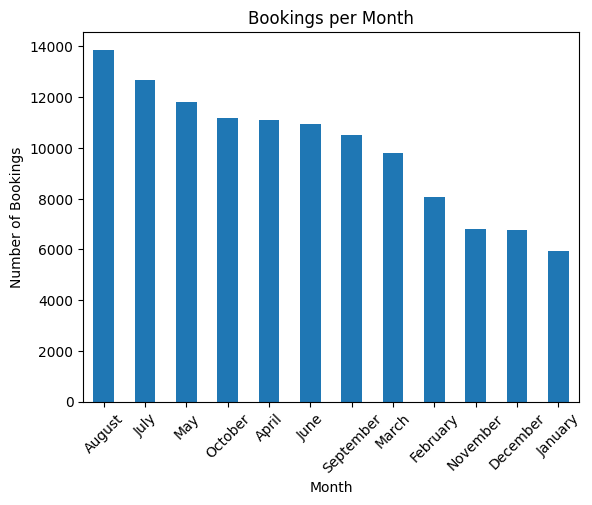

In [22]:
import matplotlib.pyplot as plt

df['arrival_date_month'].value_counts().plot(kind='bar')
plt.title("Bookings per Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.savefig("bookings_per_month.png")

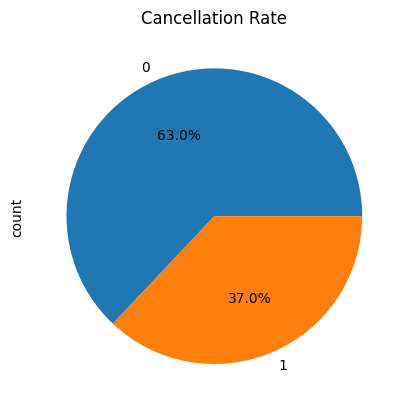

In [24]:
df['is_canceled'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Cancellation Rate")
plt.savefig("bookings_per_month.png")

## Project Overview and Conclusion

This project analyzes the **Hotel Bookings Dataset** using Python and Pandas.

The analysis focused on:
- Calculating descriptive statistics such as mean, median, standard deviation, count, and 75th percentile for 10 numeric columns.  
- Developing business questions to find insights about customer behavior, cancellations, room prices, and booking patterns.

### Key Findings:
- About **37%** of bookings were canceled.  
- **City Hotels** have a higher average daily rate (ADR) than Resort Hotels.  
- Most guests stay for **2–3 nights** only.  
- Guests with **more special requests** are less likely to cancel.  
- The **summer months (August, July)** have the highest number of bookings.  
- The average number of adults per booking is **1.86**, and children **0.1**.  
- **Canceled bookings** tend to have slightly higher room prices.

Overall, the analysis helps hotels understand customer habits and improve planning, pricing, and service quality during busy and low seasons.
